# Assignment 2 — MEG Brain-State Classification with **Mamba**

A bidirectional Mamba (selective state-space) model for 4-class MEG decoding
(`rest`, `task_motor`, `task_story_math`, `task_working_memory`), covering both the
**intra-subject** and **cross-subject** settings.

**Why Mamba?** Selective state-space models run sequence modelling in *linear* time
(vs. the quadratic cost of Transformer self-attention), which suits the long MEG
recordings (~9k time steps after downsampling). Mamba has been applied successfully to
multi-channel brain signals — e.g. *EEGMamba* (BiMamba + spatio-temporal adaptive module,
[arXiv:2407.20254](https://arxiv.org/abs/2407.20254)) and *Brain-Mamba*. We follow the
same recipe: a convolutional spatial/temporal stem followed by stacked **bidirectional**
Mamba blocks (offline classification can use both time directions).

**Dual backend.** This notebook auto-selects its Mamba implementation:
- On **CUDA (e.g. Google Colab)** it uses the official [`mamba-ssm`](https://github.com/state-spaces/mamba)
  CUDA kernels if installed (fast).
- On **Apple Silicon / CPU** it falls back to a compact **pure-PyTorch** Mamba block
  (no CUDA/Triton needed). Both expose the same `(B, L, D) -> (B, L, D)` interface.

## 0. (Optional) Colab setup

Run the next cell **only on Colab/CUDA** to enable the fast official kernels. On Apple
Silicon, skip it — the pure-PyTorch fallback is used automatically.

In [1]:
# Uncomment on Colab (CUDA) for the fast official backend:
# !pip install -q mamba-ssm causal-conv1d

## 1. Imports & configuration

In [2]:
%matplotlib inline
import os, math, time, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
torch.manual_seed(0); np.random.seed(0)

# ---- device ----
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE)

# ---- paths ----
DATA_ROOT   = Path("../data")
INTRA_TRAIN = DATA_ROOT / "Intra" / "train"
INTRA_TEST  = DATA_ROOT / "Intra" / "test"
CROSS_TRAIN = DATA_ROOT / "Cross" / "train"
CROSS_TEST1 = DATA_ROOT / "Cross" / "test1"
CROSS_TEST2 = DATA_ROOT / "Cross" / "test2"
CROSS_TEST3 = DATA_ROOT / "Cross" / "test3"

TASK_LABELS = {"rest": 0, "task_motor": 1, "task_story_math": 2, "task_working_memory": 3}
LABEL_NAMES = {v: k for k, v in TASK_LABELS.items()}
CLASS_NAMES = [LABEL_NAMES[i] for i in range(4)]
SAMPLE_RATE = 2034  # Hz

# ---- hyperparameters (analysed in the report, task c) ----
DS_FACTOR = 4      # downsample factor -> ~508 Hz effective
WIN       = 512    # window length in samples (~1.0 s @ 508 Hz)
STRIDE    = 256    # window hop (50% overlap)

MODEL_CFG = dict(d_model=128, n_layers=4, d_state=16, d_conv=4, expand=2,
                 patch=8, stem_kernel=16, dropout=0.3)
EPOCHS     = 40
BATCH_SIZE = 64
LR         = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE   = 10    # early-stopping patience (epochs)

# ---- quick-run switch: tiny/fast end-to-end check (used for smoke testing) ----
QUICK_RUN = False
if QUICK_RUN:
    EPOCHS, STRIDE = 2, 384
    print("QUICK_RUN -> EPOCHS=2, larger STRIDE, capped files")

Device: mps


## 2. Data loading & preprocessing

Helpers mirror `01_data_exploration.ipynb`. Preprocessing per file: time-wise **z-score**
(per sensor) -> **downsample** -> cut into overlapping **windows**. Each window inherits its
file's label; we also record the source-file index (`groups`) so predictions can be
aggregated back to file level at test time. Files are processed one at a time and freed
immediately, so we never hold all raw data (2.6 GB Intra / 7.4 GB Cross) in memory.

In [3]:
def get_dataset_name(filepath):
    name = Path(filepath).stem
    return "_".join(name.split("_")[:-1])

def load_h5(filepath):
    filepath = str(filepath)
    with h5py.File(filepath, "r") as f:
        return f.get(get_dataset_name(filepath))[()]   # (248, 35624)

def get_label(filepath):
    name = Path(filepath).name
    for task, label in TASK_LABELS.items():
        if name.startswith(task):
            return label
    raise ValueError(f"Unknown task in filename: {filepath}")

def list_files(folder):
    return sorted(Path(folder).glob("*.h5"))

def zscore_normalize(matrix):
    # Time-wise z-score per sensor. NOTE: MEG values are ~1e-11 T with std ~1e-12, so a
    # fixed additive epsilon (e.g. 1e-8) would dominate the denominator and crush the
    # output to ~0. Instead guard only genuinely flat sensors, preserving unit variance.
    mu  = matrix.mean(axis=1, keepdims=True)
    std = matrix.std(axis=1, keepdims=True)
    std = np.where(std < 1e-20, 1.0, std)
    return (matrix - mu) / std

def downsample(matrix, factor=DS_FACTOR):
    return matrix[:, ::factor]

def preprocess(filepath):
    m = load_h5(filepath)
    m = zscore_normalize(m)
    m = downsample(m, DS_FACTOR)
    return m.astype(np.float32)            # (248, T)

In [4]:
def make_windows(files, win=WIN, stride=STRIDE):
    """Return X (N,248,win) float32, y (N,) int64, groups (N,) int64."""
    X, y, groups = [], [], []
    for gi, f in enumerate(files):
        m = preprocess(f)                  # (248, T)
        label = get_label(f)
        T = m.shape[1]
        for s in range(0, T - win + 1, stride):
            X.append(m[:, s:s + win]); y.append(label); groups.append(gi)
        del m
    X = np.stack(X).astype(np.float32)
    return X, np.array(y, dtype=np.int64), np.array(groups, dtype=np.int64)

def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=True):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

def take_per_class(files, k):
    """Pick k files of each class (keeps all 4 classes represented in subsets)."""
    by = defaultdict(list)
    for f in files:
        by[get_label(f)].append(f)
    out = []
    for lab in sorted(by):
        out += by[lab][:k]
    return sorted(out)

# quick sanity print (one file per class so all 4 labels appear)
_demo = take_per_class(list_files(INTRA_TRAIN), 1)
_Xd, _yd, _gd = make_windows(_demo)
print("demo windows:", _Xd.shape, "labels:", np.unique(_yd), "files:", np.unique(_gd).size)

demo windows: (132, 248, 512) labels: [0 1 2 3] files: 4


## 3. Mamba backend (official **or** pure-PyTorch fallback)

`make_mamba(d_model, ...)` returns a single Mamba mixer with signature `(B, L, D) -> (B, L, D)`.
If `mamba_ssm` imports (CUDA), we use the official block; otherwise the vendored
`MambaBlock` below — a faithful, readable port (mamba-minimal style: input-dependent
`A, B, C, Δ` with a sequential selective scan) that runs anywhere.

In [5]:
try:
    from mamba_ssm import Mamba as _OfficialMamba
    HAS_OFFICIAL = True
except Exception as e:
    HAS_OFFICIAL = False
    print("Official mamba-ssm not available -> pure-PyTorch fallback. (", type(e).__name__, ")")


class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d))
    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight


class MambaBlock(nn.Module):
    """Pure-PyTorch Mamba mixer (no CUDA/Triton). I/O: (B, L, D)."""
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.d_inner = expand * d_model
        self.d_state = d_state
        self.dt_rank = math.ceil(d_model / 16)

        self.in_proj = nn.Linear(d_model, 2 * self.d_inner, bias=False)
        self.conv1d  = nn.Conv1d(self.d_inner, self.d_inner, kernel_size=d_conv,
                                 groups=self.d_inner, padding=d_conv - 1, bias=True)
        self.x_proj  = nn.Linear(self.d_inner, self.dt_rank + 2 * d_state, bias=False)
        self.dt_proj = nn.Linear(self.dt_rank, self.d_inner, bias=True)
        A = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(self.d_inner, 1)
        self.A_log = nn.Parameter(torch.log(A))          # (d_inner, d_state)
        self.D     = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)

    def _ssm(self, x):                                    # x: (B, L, d_inner)
        A = -torch.exp(self.A_log)                        # (d_inner, d_state)
        x_dbl = self.x_proj(x)                            # (B, L, dt_rank+2N)
        delta, B, C = x_dbl.split([self.dt_rank, self.d_state, self.d_state], dim=-1)
        delta = F.softplus(self.dt_proj(delta))           # (B, L, d_inner)
        dA = torch.exp(torch.einsum("bld,dn->bldn", delta, A))
        dBx = torch.einsum("bld,bln,bld->bldn", delta, B, x)
        b, l, d = x.shape
        h = torch.zeros(b, d, self.d_state, device=x.device, dtype=x.dtype)
        ys = []
        for i in range(l):
            h = dA[:, i] * h + dBx[:, i]
            ys.append(torch.einsum("bdn,bn->bd", h, C[:, i]))
        y = torch.stack(ys, dim=1)                        # (B, L, d_inner)
        return y + x * self.D

    def forward(self, x):                                 # (B, L, D)
        b, l, _ = x.shape
        xz = self.in_proj(x)
        xc, z = xz.chunk(2, dim=-1)                       # each (B, L, d_inner)
        xc = self.conv1d(xc.transpose(1, 2))[..., :l].transpose(1, 2)
        xc = F.silu(xc)
        y = self._ssm(xc)
        y = y * F.silu(z)
        return self.out_proj(y)


def make_mamba(d_model, d_state=16, d_conv=4, expand=2):
    if HAS_OFFICIAL and DEVICE.type == "cuda":
        return _OfficialMamba(d_model=d_model, d_state=d_state, d_conv=d_conv, expand=expand)
    return MambaBlock(d_model, d_state=d_state, d_conv=d_conv, expand=expand)

print("Backend:", "official mamba-ssm (CUDA)" if (HAS_OFFICIAL and DEVICE.type == "cuda")
      else "pure-PyTorch MambaBlock")

Official mamba-ssm not available -> pure-PyTorch fallback. ( ModuleNotFoundError )
Backend: pure-PyTorch MambaBlock


## 4. Bidirectional Mamba classifier

1. **Conv stem** `Conv1d(248 -> d_model, k=stem_kernel, stride=patch)` mixes the 248 sensors
   spatially and patches time into tokens (e.g. 512/8 = 64 tokens) — keeping the pure-PyTorch
   scan cheap.
2. **N x BiMamba blocks**: each runs the mixer forward and on the reversed sequence
   (RMSNorm + residual), summing both directions.
3. **Mean-pool** over tokens -> linear head -> 4 logits.

In [6]:
class BiMamba(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.norm = RMSNorm(d_model)
        self.fwd  = make_mamba(d_model, d_state, d_conv, expand)
        self.bwd  = make_mamba(d_model, d_state, d_conv, expand)
    def forward(self, x):                                 # (B, L, D)
        h = self.norm(x)
        y_f = self.fwd(h)
        y_b = self.bwd(h.flip(1)).flip(1)
        return x + y_f + y_b


class MEGMambaClassifier(nn.Module):
    def __init__(self, n_sensors=248, n_classes=4, d_model=128, n_layers=4,
                 d_state=16, d_conv=4, expand=2, patch=8, stem_kernel=16, dropout=0.3):
        super().__init__()
        self.stem = nn.Conv1d(n_sensors, d_model, kernel_size=stem_kernel,
                              stride=patch, padding=stem_kernel // 2)
        self.layers = nn.ModuleList([
            BiMamba(d_model, d_state, d_conv, expand) for _ in range(n_layers)])
        self.norm_f  = RMSNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(d_model, n_classes)
    def forward(self, x):                                 # (B, n_sensors, L)
        x = self.stem(x).transpose(1, 2)                 # (B, L', d_model)
        for layer in self.layers:
            x = layer(x)
        x = self.norm_f(x).mean(dim=1)                   # (B, d_model)
        return self.head(self.dropout(x))


def build_model(**overrides):
    cfg = {**MODEL_CFG, **overrides}
    return MEGMambaClassifier(**cfg)

# parameter count
_m = build_model()
print("Model params:", sum(p.numel() for p in _m.parameters()) / 1e3, "K")
del _m

Model params: 1441.028 K


## 5. Training & evaluation utilities

`train_model` uses AdamW + `ReduceLROnPlateau`, tracks train/val loss & accuracy, and
early-stops on validation loss. `evaluate_files` predicts every window of each test file
and **aggregates window logits per file** (mean) to a single file-level prediction —
reporting both window-level and file-level accuracy plus a confusion matrix.

In [7]:
@torch.no_grad()
def _eval_loader(model, loader, crit):
    model.eval()
    tot_loss = tot_correct = n = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        out = model(xb)
        tot_loss += crit(out, yb).item() * xb.size(0)
        tot_correct += (out.argmax(1) == yb).sum().item()
        n += xb.size(0)
    return tot_loss / n, tot_correct / n

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR,
                weight_decay=WEIGHT_DECAY, patience=PATIENCE, verbose=True):
    model.to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)
    crit  = nn.CrossEntropyLoss()
    hist  = {k: [] for k in ("train_loss", "train_acc", "val_loss", "val_acc")}
    # select the best checkpoint by val ACCURACY (val loss can rise from over-confidence
    # while accuracy still improves); tie-break on lower val loss.
    best_acc, best_loss, best_state, bad = -1.0, float("inf"), None, 0

    for ep in range(1, epochs + 1):
        model.train()
        tl = tc = n = 0
        t0 = time.time()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            out  = model(xb)
            loss = crit(out, yb)
            loss.backward(); opt.step()
            tl += loss.item() * xb.size(0)
            tc += (out.argmax(1) == yb).sum().item(); n += xb.size(0)
        tr_loss, tr_acc = tl / n, tc / n
        va_loss, va_acc = _eval_loader(model, val_loader, crit)
        sched.step(va_loss)
        for k, v in zip(hist, (tr_loss, tr_acc, va_loss, va_acc)):
            hist[k].append(v)
        if verbose:
            print(f"ep {ep:02d}  train {tr_loss:.3f}/{tr_acc:.3f}  "
                  f"val {va_loss:.3f}/{va_acc:.3f}  ({time.time()-t0:.1f}s)")
        improved = (va_acc > best_acc + 1e-4) or (
            abs(va_acc - best_acc) <= 1e-4 and va_loss < best_loss - 1e-4)
        if improved:
            best_acc, best_loss = max(best_acc, va_acc), va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                if verbose: print(f"early stop @ epoch {ep}  (best val acc {best_acc:.3f})")
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, hist

In [8]:
@torch.no_grad()
def evaluate_files(model, files, win=WIN, stride=STRIDE):
    """File-level evaluation via mean-logit aggregation over each file's windows."""
    model.eval()
    y_true, y_pred = [], []
    win_correct = win_total = 0
    for f in files:
        m = preprocess(f); T = m.shape[1]; label = get_label(f)
        wins = np.stack([m[:, s:s + win] for s in range(0, T - win + 1, stride)])
        xb = torch.from_numpy(wins).to(DEVICE)
        logits = model(xb)
        win_correct += (logits.argmax(1) == label).sum().item(); win_total += len(wins)
        y_pred.append(logits.mean(0).argmax().item()); y_true.append(label)
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return dict(win_acc=win_correct / win_total,
                file_acc=float((y_pred == y_true).mean()),
                y_true=y_true, y_pred=y_pred)

def plot_history(hist, title):
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(hist["train_loss"], label="train"); ax[0].plot(hist["val_loss"], label="val")
    ax[0].set_title(f"{title} — loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(hist["train_acc"], label="train"); ax[1].plot(hist["val_acc"], label="val")
    ax[1].set_title(f"{title} — accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

def plot_confusion(res, title):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=list(range(4)))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        cmap="Blues", xticks_rotation=30, colorbar=False)
    plt.title(f"{title}  (file acc={res['file_acc']:.2f})"); plt.tight_layout(); plt.show()

## 6. Intra-subject classification

Train on `Intra/train` (subject 105923), holding out a few windows for validation; test on
`Intra/test`. Single-subject decoding is the easier setting and validates the model.

intra train/val windows: (858, 248, 512) (198, 248, 512)


ep 01  train 1.633/0.282  val 1.273/0.460  (30.9s)


ep 02  train 1.050/0.510  val 1.094/0.465  (28.8s)


ep 03  train 0.802/0.661  val 0.954/0.556  (28.4s)


ep 04  train 0.575/0.769  val 1.632/0.480  (28.3s)


...

ep 17  train 0.004/1.000  val 1.833/0.571  (27.8s)


ep 18  train 0.004/1.000  val 1.837/0.571  (26.9s)


ep 19  train 0.004/1.000  val 1.842/0.571  (27.0s)


ep 20  train 0.004/1.000  val 1.845/0.571  (27.8s)


ep 21  train 0.003/1.000  val 1.847/0.571  (26.8s)
early stop @ epoch 21  (best val acc 0.581)


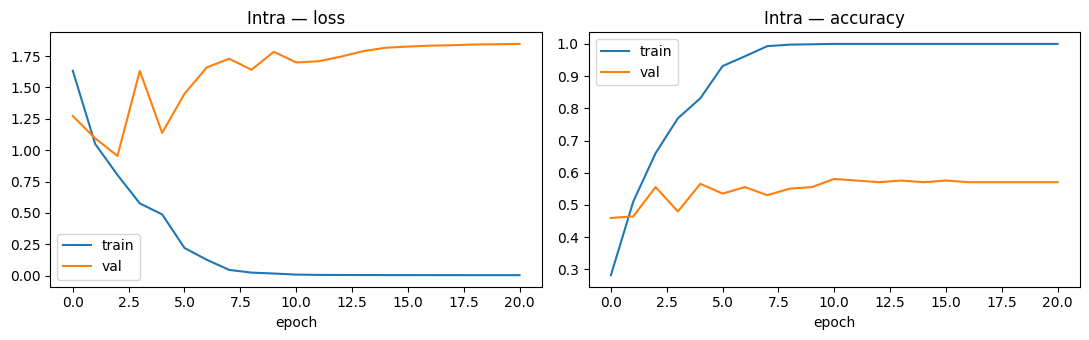

In [9]:
def split_train_val(X, y, groups, val_frac=0.2, seed=0):
    """Group-aware split: whole files go to either train or val (no window leakage)."""
    rng = np.random.default_rng(seed)
    uniq = np.unique(groups); rng.shuffle(uniq)
    n_val = max(1, int(round(val_frac * len(uniq))))
    val_g = set(uniq[:n_val].tolist())
    vm = np.isin(groups, list(val_g))
    return X[~vm], y[~vm], X[vm], y[vm]

intra_train_files = list_files(INTRA_TRAIN)
intra_test_files  = list_files(INTRA_TEST)
if QUICK_RUN:
    intra_train_files = take_per_class(intra_train_files, 2)

Xtr, ytr, gtr = make_windows(intra_train_files)
Xtr2, ytr2, Xva, yva = split_train_val(Xtr, ytr, gtr)
print("intra train/val windows:", Xtr2.shape, Xva.shape)

intra_model = build_model()
intra_model, intra_hist = train_model(
    intra_model, make_loader(Xtr2, ytr2), make_loader(Xva, yva, shuffle=False))
plot_history(intra_hist, "Intra")

Intra  window-acc=0.580  file-acc=0.750


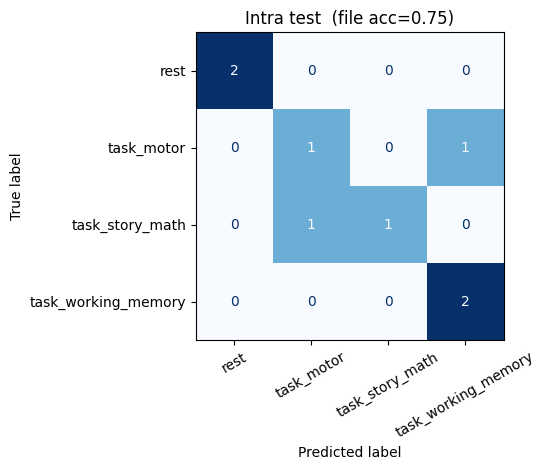

In [10]:
intra_res = evaluate_files(intra_model, intra_test_files)
print(f"Intra  window-acc={intra_res['win_acc']:.3f}  file-acc={intra_res['file_acc']:.3f}")
plot_confusion(intra_res, "Intra test")

## 7. Cross-subject classification

Train on `Cross/train` (subjects 113922 & 164636), validate on a held-out file group, and
test on three **unseen** subjects (`test1/2/3`). This is the harder setting — distribution
shift across subjects usually lowers accuracy relative to intra.

cross train/val windows: (1683, 248, 512) (429, 248, 512)


ep 01  train 1.530/0.292  val 1.151/0.487  (53.6s)


ep 02  train 0.941/0.578  val 0.896/0.606  (52.6s)


ep 03  train 0.602/0.757  val 0.858/0.655  (52.2s)


ep 04  train 0.431/0.845  val 0.869/0.671  (52.1s)


...

ep 20  train 0.001/1.000  val 0.555/0.839  (53.9s)


ep 21  train 0.001/1.000  val 0.557/0.839  (52.3s)


ep 22  train 0.001/1.000  val 0.557/0.839  (52.2s)


ep 23  train 0.001/1.000  val 0.556/0.839  (52.7s)


ep 24  train 0.001/1.000  val 0.558/0.839  (52.6s)
early stop @ epoch 24  (best val acc 0.853)


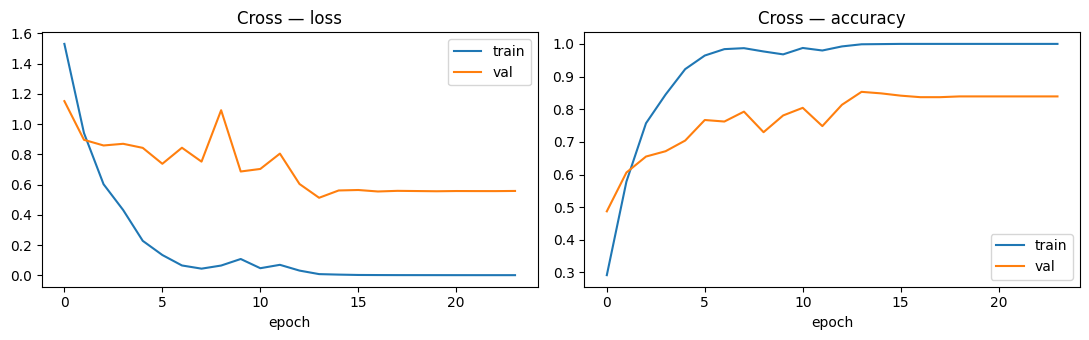

In [11]:
cross_train_files = list_files(CROSS_TRAIN)
cross_tests = {"test1": list_files(CROSS_TEST1),
               "test2": list_files(CROSS_TEST2),
               "test3": list_files(CROSS_TEST3)}
if QUICK_RUN:
    cross_train_files = take_per_class(cross_train_files, 2)
    cross_tests = {k: take_per_class(v, 1) for k, v in cross_tests.items()}

Xc, yc, gc = make_windows(cross_train_files)
Xc2, yc2, Xcv, ycv = split_train_val(Xc, yc, gc, val_frac=0.2)
print("cross train/val windows:", Xc2.shape, Xcv.shape)

cross_model = build_model()
cross_model, cross_hist = train_model(
    cross_model, make_loader(Xc2, yc2), make_loader(Xcv, ycv, shuffle=False))
plot_history(cross_hist, "Cross")

Cross test1  window-acc=0.528  file-acc=0.875


Cross test2  window-acc=0.555  file-acc=0.625


Cross test3  window-acc=0.606  file-acc=0.875


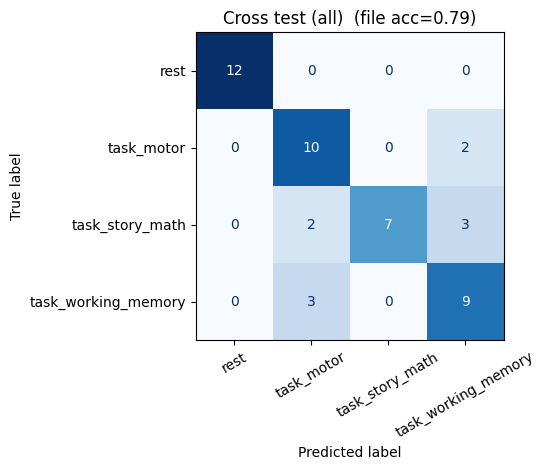

In [12]:
cross_res = {}
for name, files in cross_tests.items():
    if not files:
        continue
    cross_res[name] = evaluate_files(cross_model, files)
    r = cross_res[name]
    print(f"Cross {name}  window-acc={r['win_acc']:.3f}  file-acc={r['file_acc']:.3f}")

# combined confusion matrix over all cross test subjects
all_true = np.concatenate([r["y_true"] for r in cross_res.values()])
all_pred = np.concatenate([r["y_pred"] for r in cross_res.values()])
plot_confusion({"y_true": all_true, "y_pred": all_pred,
                "file_acc": float((all_true == all_pred).mean())}, "Cross test (all)")

## 8. Intra vs. cross — summary

In [13]:
rows = [("Intra (105923)", intra_res["win_acc"], intra_res["file_acc"])]
for name, r in cross_res.items():
    rows.append((f"Cross {name}", r["win_acc"], r["file_acc"]))
if cross_res:
    rows.append(("Cross (mean)",
                 np.mean([r["win_acc"] for r in cross_res.values()]),
                 np.mean([r["file_acc"] for r in cross_res.values()])))

print(f"{'Setting':<18}{'window-acc':>12}{'file-acc':>12}")
print("-" * 42)
for name, wa, fa in rows:
    print(f"{name:<18}{wa:>12.3f}{fa:>12.3f}")

Setting             window-acc    file-acc
------------------------------------------
Intra (105923)           0.580       0.750
Cross test1              0.528       0.875
Cross test2              0.555       0.625
Cross test3              0.606       0.875
Cross (mean)             0.563       0.792


## 9. Task (d) — improving the cross-subject model

Cross-subject accuracy typically trails intra-subject because of inter-subject distribution
shift. Ideas to try here (pick one and implement to answer task **d**):

- **Stronger normalisation** — per-window z-scoring (already partly done) or per-subject
  channel statistics to reduce subject-specific offsets.
- **Capacity / depth** — more Mamba layers or larger `d_model` / `d_state`.
- **Data augmentation** — additive noise, time-shift/crop, sensor dropout to encourage
  subject-invariant features.
- **Mixup** across windows, or label smoothing.

Implement and compare against the section-7 baseline; report the change in `test1/2/3`
accuracy and discuss in the report.

In [14]:
# TODO (task d): implement one improvement and re-evaluate, e.g.
#   - add gaussian noise augmentation inside the training loop, or
#   - bump MODEL_CFG['n_layers'] / 'd_model' and retrain cross_model.
# Compare the new cross test accuracy against section 7.